In [1]:
import os
import gc
import json
import time
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
from sklearn.metrics import (confusion_matrix, classification_report, ConfusionMatrixDisplay, fbeta_score,
                             recall_score, balanced_accuracy_score, f1_score, precision_recall_fscore_support)
import matplotlib.pyplot as plt
import seaborn as sns
from torch.optim import Adam 
import torch.nn.functional as F
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="torch.optim.lr_scheduler")

device = torch.device("cuda" if torch.cuda.is_available() else 
                     ("mps" if torch.backends.mps.is_available() else "cpu"))

def clear_memory():
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
sys.path.append(str(ROOT))

from Utils.project_utils import *
import Utils.constants1 as c
from Utils.transforms import *
from Utils.MushroomDataset import *
from Utils.dataLoaders import *

In [3]:
print(f"Using device: {device}")

Using device: mps


In [4]:
SPLIT_DIR = Path.cwd().resolve() / "Data" / "splits"

In [5]:
# Load the datasets
train = pd.read_csv(SPLIT_DIR / "train.csv")
val = pd.read_csv(SPLIT_DIR / "val.csv")
test = pd.read_csv(SPLIT_DIR / "test.csv")

In [6]:
# Load the class mapping
with open(SPLIT_DIR / "class_to_idx.json", "r") as f:
    train_class_to_idx = json.load(f)

In [7]:
# Define transforms (fixing the syntax error from before)
train_tfms_mild = get_train_tfms_mild() 
train_tfms_strong = get_train_tfms_strong() 
val_tfms = get_val_tfms()

print("All files loaded successfully!")

All files loaded successfully!


In [8]:
save_dir = PROJECT_ROOT / "Graphs"
save_dir.mkdir(parents=True, exist_ok=True)

In [9]:
CLASSES = sorted(train["class"].unique().tolist())

In [10]:
loaders = make_loaders(
    train,
    val,
    test,
    train_tfms_mild,
    train_tfms_strong,
    val_tfms,
    train_class_to_idx,
    CLASSES,
    c.BATCH_SIZE,
    c.NUM_WORKERS,
    device,
)

loaders

{'train_loader_mild': <torch.utils.data.dataloader.DataLoader at 0x390673690>,
 'train_loader_strong': <torch.utils.data.dataloader.DataLoader at 0x106cbe410>,
 'val_loader': <torch.utils.data.dataloader.DataLoader at 0x3906697d0>,
 'test_loader': <torch.utils.data.dataloader.DataLoader at 0x390673590>}

In [11]:
train_loader = loaders["train_loader_strong"]
val_loader = loaders["val_loader"]
test_loader = loaders["test_loader"]

In [12]:
toxic_idx = train_class_to_idx['toxic']

In [13]:
class_weights = torch.tensor([1.0, 1.0, 8.0], dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
print(f"Using class weights: [1.0, 1.0, 8.0] (focus on toxic class!)")

Using class weights: [1.0, 1.0, 8.0] (focus on toxic class!)


## Training and Validation

### Load RESNET50 Model

In [14]:
clear_memory()

In [15]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
model = model.to(device)

In [16]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

In [17]:
# warmup for 5 epochs, then Cosine Decay
num_epochs = 50

warmup_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=5)

In [18]:
main_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs - 5, eta_min=1e-6)

In [19]:
scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup_scheduler, main_scheduler], milestones=[5])

In [20]:
BEST_MODEL_PATH = Path.cwd() / "best_models" / "resnet50_robustv3_best.pth"
BEST_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
print("Model initialized successfully!")

Model initialized successfully!


In [21]:
def run_one_epoch(model, loader, criterion, optimizer, device, is_train=False, return_preds=False):
    running_loss, running_correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    
    start_time = time.time()
    model.train() if is_train else model.eval()
    num_batches = len(loader)
    
    for i, (img, labels) in enumerate(loader):
        img, labels = img.to(device), labels.to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            outputs = model(img)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                outputs = model(img)
                loss = criterion(outputs, labels)

        preds = outputs.argmax(1)
        batch_size = img.size(0)
        running_loss += loss.item() * batch_size
        running_correct += (preds == labels).sum().item()
        total += batch_size

        if (i + 1) % 5 == 0 or (i + 1) == num_batches:
            elapsed = time.time() - start_time
            print(f"  Batch {i+1}/{num_batches} | Loss: {loss.item():.4f} | "
                  f"Acc: {running_correct/total:.4f} | Time: {elapsed:.1f}s", end='\r')

        if return_preds:
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
            
        # Clean up memory
        del img, labels, outputs, loss, preds
        if i % 10 == 0 and device.type == 'mps':
            torch.mps.empty_cache()

    print()

    if return_preds:
        all_labels = torch.cat(all_labels).numpy()
        all_preds  = torch.cat(all_preds).numpy()
        # Calculate F2 score with beta=2 (recall-focused)
        f2 = fbeta_score(all_labels, all_preds, beta=2, average='macro')
        return (running_loss / total), (running_correct / total), total, all_labels, all_preds, f2
    else:
        return (running_loss / total), (running_correct / total), total, None, None, None


### Train model with early stopping based on F2 score (recall-focused)
    
    Args:
        model: The neural network
        train_loader: Training data loader
        val_loader: Validation data loader
        criterion: Loss function
        optimizer: Optimizer
        num_epochs: Maximum number of epochs
        device: Device to train on
        patience: Early stopping patience
    
    Returns:
        Trained model (best version loaded)


In [22]:
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, patience=5):

    # Track best F2 score
    best_val_f2 = -float("inf")  
    bad_epochs = 0
    total_start_time = time.time()

    for epoch in range(num_epochs):
        epoch_start = time.time()
        print(f"\n{'='*50}")
        print(f">>> Epoch {epoch + 1}/{num_epochs} start")
        print(f"{'='*50}")

        # Training 
        train_loss, train_acc, _, _, _, _ = run_one_epoch(
            model, train_loader, criterion, optimizer, device, is_train=True
        )
        
        # Validation - with F2 score calculation
        val_loss, val_acc, _, val_labels, val_preds, val_f2 = run_one_epoch(
            model, val_loader, criterion, optimizer, device, is_train=False, return_preds=True
        )

        epoch_time = time.time() - epoch_start
        print(f"\n>>> Epoch {epoch + 1} Complete | Time: {epoch_time:.1f}s")
        print(f"{'-'*50}")
        print(f"TRAIN:   Loss = {train_loss:.4f} | Accuracy = {train_acc:.4f}")
        print(f"VALID:   Loss = {val_loss:.4f} | Accuracy = {val_acc:.4f}")
        print(f"VALID:   F2 Score (macro) = {val_f2:.4f}  <-- EARLY STOPPING METRIC")
        print(f"{'-'*50}")

        # early stopping based on F2 score (prioritizes recall)
        if val_f2 > best_val_f2:
            best_val_f2 = val_f2
            bad_epochs = 0
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print(f"New Best Model Saved!")
            print(f"Best Val F2: {best_val_f2:.4f}")
        else:
            bad_epochs += 1
            print(f"No F2 improvement. Patience: {bad_epochs}/{patience}")
            print(f"Current F2: {val_f2:.4f} | Best F2: {best_val_f2:.4f}")
            
            if bad_epochs >= patience:
                print(f"\n{'!'*50}")
                print(f"Early stopping triggered after {epoch + 1} epochs")
                print(f"{'!'*50}")
                break
        
        # Clean up memory
        gc.collect()
        if device.type == 'mps':
            torch.mps.empty_cache()
        
        print(f"{'='*50}")

    total_time = (time.time() - total_start_time) / 60
    print(f"\n{'='*50}")
    print(f">>> Training Complete!")
    print(f"Total Time: {total_time:.1f} minutes")
    print(f"Best Val F2: {best_val_f2:.4f}")
    print(f"{'='*50}")
    
    # Load the best model
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
    return model

In [23]:
model = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=30,      
    device=device,
    patience=5          
)


>>> Epoch 1/30 start
  Batch 151/151 | Loss: 0.3903 | Acc: 0.3428 | Time: 608.3s
  Batch 19/19 | Loss: 0.4263 | Acc: 0.4294 | Time: 28.0s

>>> Epoch 1 Complete | Time: 636.5s
--------------------------------------------------
TRAIN:   Loss = 0.5629 | Accuracy = 0.3428
VALID:   Loss = 0.3730 | Accuracy = 0.4294
VALID:   F2 Score (macro) = 0.3666  <-- EARLY STOPPING METRIC
--------------------------------------------------
New Best Model Saved!
Best Val F2: 0.3666

>>> Epoch 2/30 start
  Batch 151/151 | Loss: 0.3420 | Acc: 0.5341 | Time: 577.5s
  Batch 19/19 | Loss: 0.3417 | Acc: 0.6939 | Time: 28.0s

>>> Epoch 2 Complete | Time: 605.7s
--------------------------------------------------
TRAIN:   Loss = 0.3648 | Accuracy = 0.5341
VALID:   Loss = 0.2962 | Accuracy = 0.6939
VALID:   F2 Score (macro) = 0.6821  <-- EARLY STOPPING METRIC
--------------------------------------------------
New Best Model Saved!
Best Val F2: 0.6821

>>> Epoch 3/30 start
  Batch 151/151 | Loss: 0.2997 | Acc: 0.69

In [24]:
models_dir = PROJECT_ROOT / "best_models"
models_dir.mkdir(parents=True, exist_ok=True)
model_save_path = models_dir / "resnet50_Robustv3_Final.pth"
torch.save(model.state_dict(), model_save_path)

In [25]:
print("FINAL EVALUATION ON TEST SET (standard prediction)")
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for img, labels in test_loader:
        img = img.to(device)
        outputs = model(img)
        preds = outputs.argmax(dim=1) 
        
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

y_true = torch.cat(all_labels).numpy()
y_pred = torch.cat(all_preds).numpy()

FINAL EVALUATION ON TEST SET (standard prediction)


In [26]:
accuracy = np.mean(y_true == y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)
f1_m = f1_score(y_true, y_pred, average='macro')
f1_w = f1_score(y_true, y_pred, average='weighted')
prec, rec, f1_tox, _ = precision_recall_fscore_support(y_true, y_pred, labels=[toxic_idx], beta=1.0, zero_division=0)
_, _, f2_tox, _ = precision_recall_fscore_support(y_true, y_pred, labels=[toxic_idx], beta=2.0, zero_division=0)

In [27]:
print(f"\nOverall Accuracy: {accuracy:.4f} (Balanced: {bal_acc:.4f})")
print(f"Macro F1: {f1_m:.4f} | Weighted F1: {f1_w:.4f}")
print(f"Toxic - Precision: {prec[0]:.4f}, Recall: {rec[0]:.4f}, F1: {f1_tox[0]:.4f}, F2: {f2_tox[0]:.4f}")
print("-" * 60)
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))


Overall Accuracy: 0.8887 (Balanced: 0.8887)
Macro F1: 0.8886 | Weighted F1: 0.8886
Toxic - Precision: 0.9004, Recall: 0.9234, F1: 0.9118, F2: 0.9187
------------------------------------------------------------

Detailed Classification Report:
                      precision    recall  f1-score   support

conditionally_edible     0.8833    0.8816    0.8824      1605
              edible     0.8820    0.8611    0.8715      1606
               toxic     0.9004    0.9234    0.9118      1606

            accuracy                         0.8887      4817
           macro avg     0.8886    0.8887    0.8886      4817
        weighted avg     0.8886    0.8887    0.8886      4817



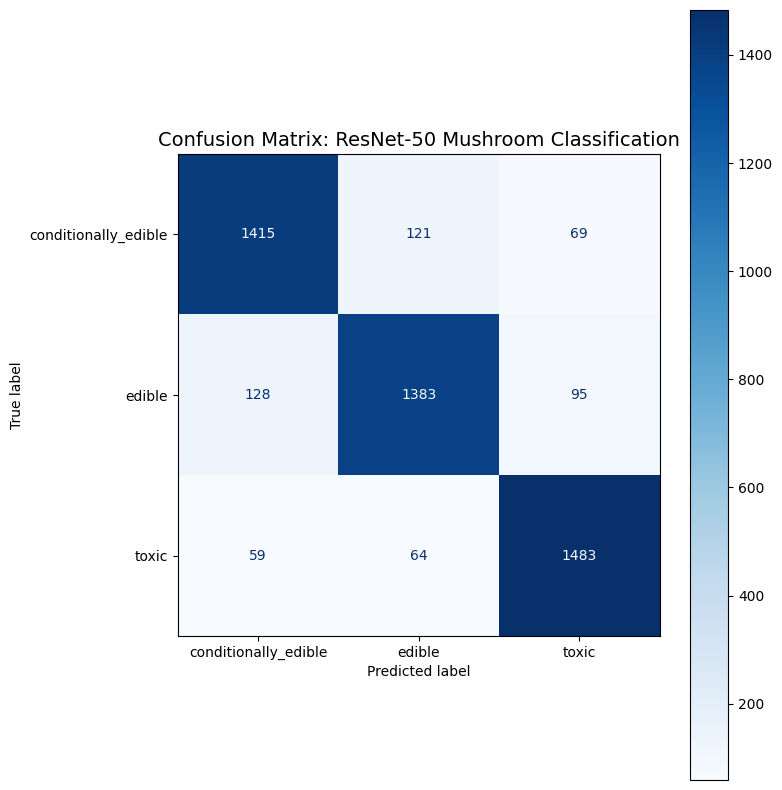

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", values_format='d')
plt.title("Confusion Matrix: ResNet-50 Mushroom Classification", fontsize=14)
plt.tight_layout()
plt.savefig(save_dir / "Resnet50" / "resnet50_robust3_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

In [29]:
clear_memory()